# Project Statistical Methods for Decision Making: FoodHub Data Analysis

**Marks: 60 points**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are a Data Scientist at Foodhub and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### **Please read the instructions carefully before starting the project.** 
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned. Read along carefully to complete the project.
* Blanks '_______' are provided in the notebook that 
needs to be filled with an appropriate code to get the correct result. Please replace the blank with the right code snippet. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space. 
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw an error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* You can the results/observations derived from the analysis here and use them to create your final presentation.


### Let us start by importing the required libraries

In [1]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# Read the data
df = pd.read_csv('foodhub_order.csv') 

df.head() 

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [4]:
# Check the shape of the dataset
df.shape 

(1898, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.  [1 Mark]

In [6]:
# Checking for missing values in the data
missing_values=df.isnull().sum()

#Write the appropriate function to print the sum of null values for each column
print("Missing Values:")
print(missing_values)


Missing Values:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [7]:
# summary statistics of the numerical data
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [8]:
minimum_prep_time=df['food_preparation_time'].min()

maximum_prep_time=df['food_preparation_time'].max()

Average_prep_time=df['food_preparation_time'].mean()

print('Minimum Food Preparation Time:', minimum_prep_time)

print('Maximum Food Preparation Time:', maximum_prep_time)

print('Average Food Preparation Time:', Average_prep_time)




Minimum Food Preparation Time: 20
Maximum Food Preparation Time: 35
Average Food Preparation Time: 27.371970495258168


### **Question 5:** How many orders are not rated? [1 mark]

In [9]:
df['rating'].value_counts() 

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [8 marks]

#### Order ID

In [10]:
# check unique order ID
df['order_id'].nunique()  

1898

#### Customer ID

In [11]:
# check unique customer ID
df['customer_id'].nunique() 

1200

#### Restaurant name

In [12]:
# check unique Restaurant Name
df['restaurant_name'].nunique()  

178

#### Cuisine type

In [13]:
# Check unique cuisine type
df['cuisine_type'].nunique()

14

<Axes: xlabel='cuisine_type', ylabel='count'>

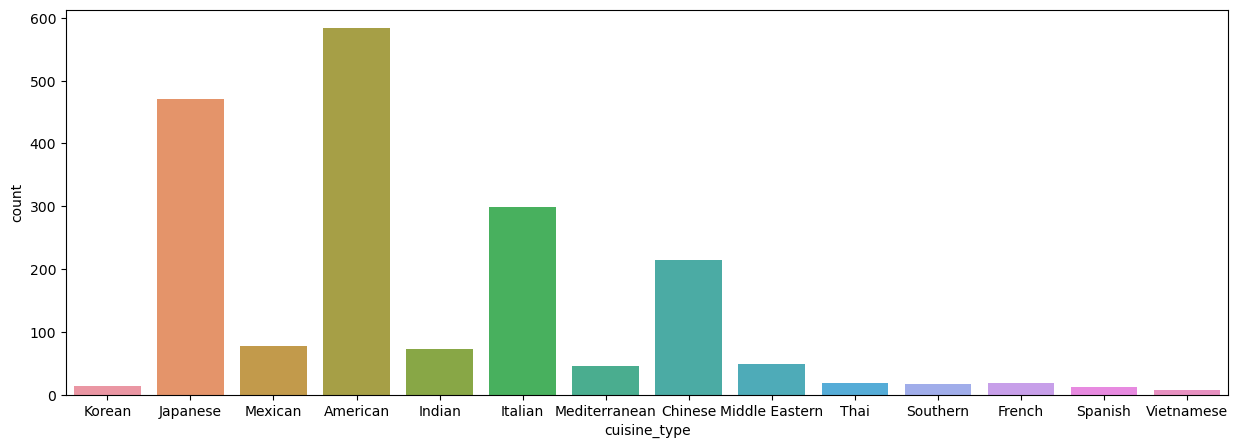

In [14]:
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type') 

#### Cost of the order

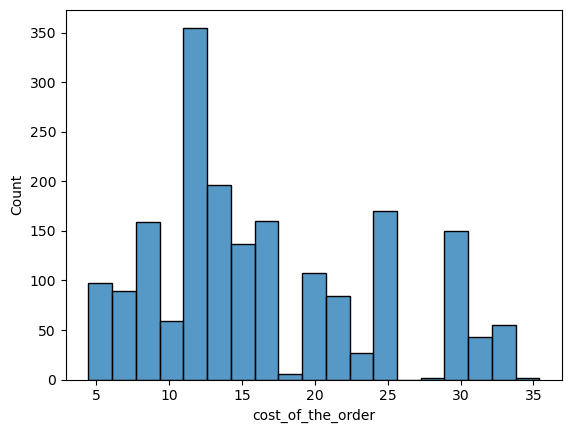

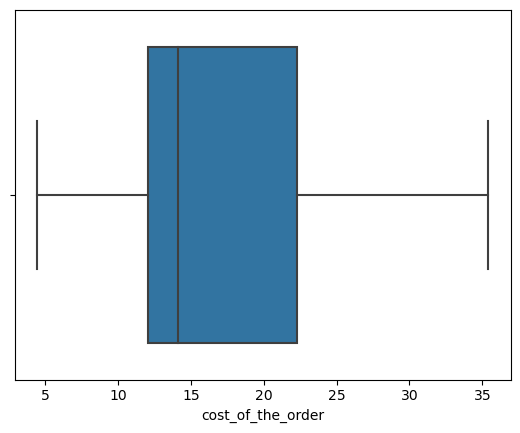

In [15]:
sns.histplot(data=df,x='cost_of_the_order') ## Histogram for the cost of order
plt.show()
sns.boxplot(data=df,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show() 

#### Day of the week

In [16]:
# # Check the unique values
df['day_of_the_week'].nunique() 

2

<Axes: xlabel='day_of_the_week', ylabel='count'>

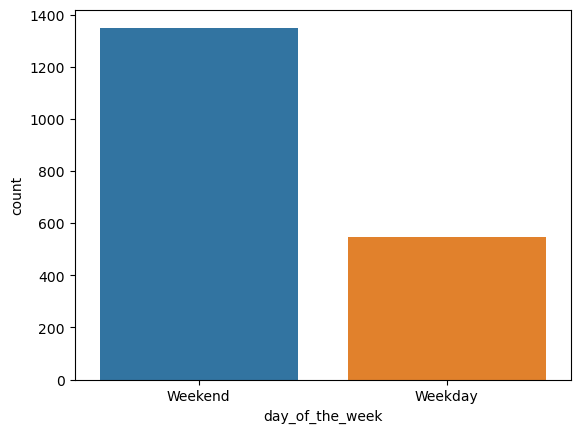

In [17]:
sns.countplot(data = df, x = 'day_of_the_week')

#### Rating

In [18]:
# Check the unique values
df['rating'].nunique() 

4

<Axes: xlabel='rating', ylabel='count'>

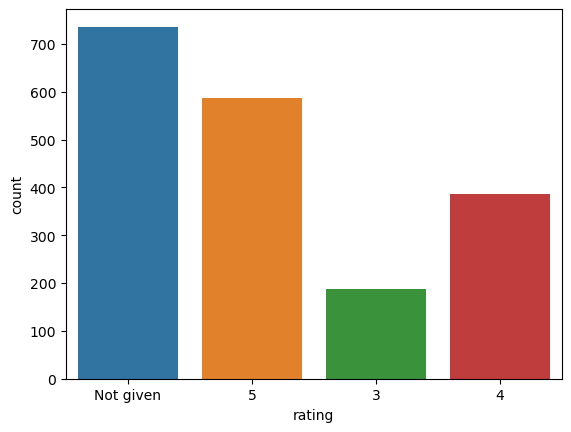

In [19]:
sns.countplot(data = df, x = 'rating') 

#### Food Preparation time

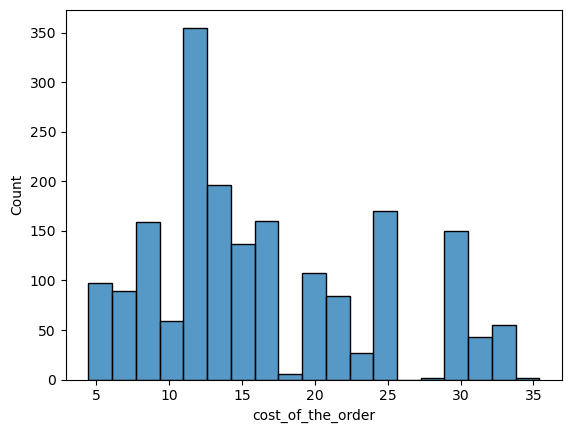

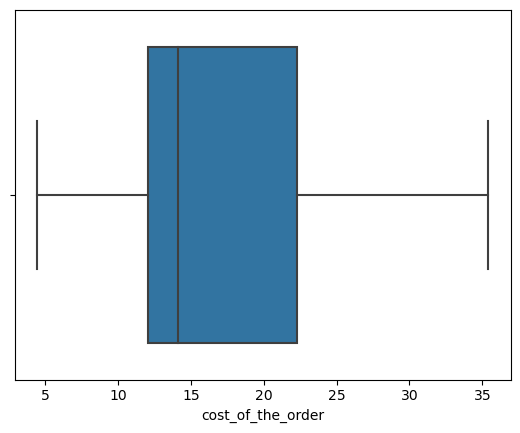

In [20]:
sns.histplot(data=df,x='cost_of_the_order') 
plt.show()
sns.boxplot(data=df,x='cost_of_the_order') 
plt.show()

#### Delivery time

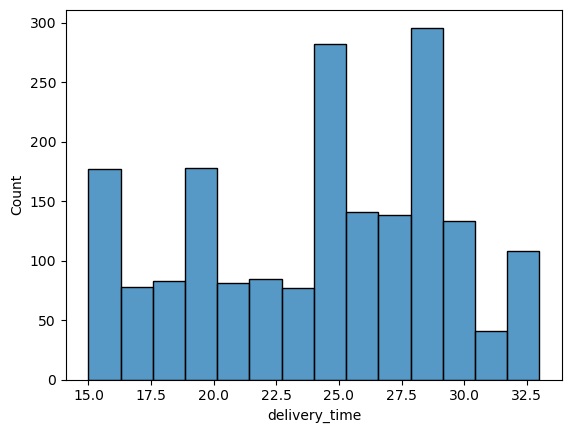

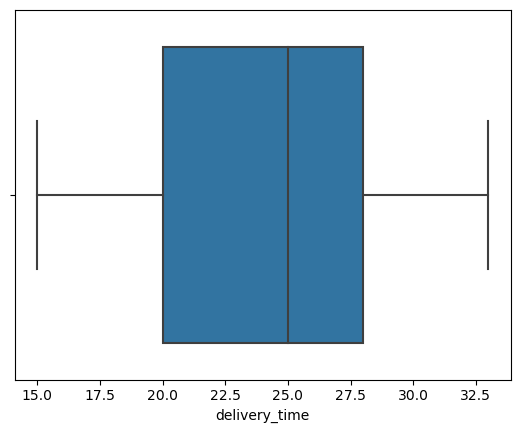

In [21]:
sns.histplot(data=df,x='delivery_time') 
plt.show()
sns.boxplot(data=df,x='delivery_time')
plt.show()

### **Question 7:** Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [22]:
# Get top 5 restaurants with highest number of orders
top_5_restaurants=df['restaurant_name'].value_counts().head(5) 
top_5_restaurants

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

In [23]:
# Get top 5 restaurants with least number of orders
top_5_restaurants_least_orders=df['restaurant_name'].value_counts().tail(51) 
top_5_restaurants_least_orders

restaurant_name
Mira Sushi                       2
Le Zie 2000 Trattoria            1
Cafe de La Esquina               1
Sarabeth's West                  1
Frank Restaurant                 1
Hiroko's Place                   1
Rye House                        1
Lamarca Pasta                    1
67 Burger                        1
Lucky Strike                     1
Paul & Jimmy's                   1
Hampton Chutney Co.              1
Wa Jeal                          1
Hunan Manor                      1
Moonstruck on Second             1
Il Bambino                       1
Nha Trang One                    1
Market Table                     1
Emporio                          1
Galli Restaurant                 1
Coppola's East                   1
Kori Restaurant and Bar          1
Woorijip                         1
Crema Restaurante                1
The MasalaWala                   1
Anjappar Chettinad               1
Big Wong Restaurant _¤¾Ñ¼       1
Klong                            1
Haru

### **Question 8:** Which is the most popular cuisine on weekends? [1 mark]

In [24]:
# Get most popular cuisine on weekends
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts().idxmax()


'American'

In [25]:
# Get least popular cuisine on weekend
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts().idxmin()


'Vietnamese'

In [26]:
# Get most popular cuisine on weekdays
df_weekdays = df[df['day_of_the_week'] == 'Weekday']
df_weekdays['cuisine_type'].value_counts().idxmax()


'American'

In [27]:
# Get least popular cuisine on weekdays
df_weekdays = df[df['day_of_the_week'] == 'Weekday']
df_weekdays['cuisine_type'].value_counts().idxmin()


'Spanish'

### **Question 9:** What percentage of the orders cost more than 20 dollars? [2 marks]


In [28]:
# Get orders that cost above 20 dollars
df_greater_than_20 = df[df['cost_of_the_order']>20]

# Calculate the number of total orders where the cost is above 20 dollars
print('The number of total orders that cost above 20 dollars is:', df_greater_than_20.shape[0])

# Calculate percentage of such orders in the dataset
percentage = (df_greater_than_20.shape[0] / df.shape[0]) * 100

print("Percentage of orders above 20 dollars:", round(percentage, 2), '%')

The number of total orders that cost above 20 dollars is: 555
Percentage of orders above 20 dollars: 29.24 %


### **Question 10:** What is the mean order delivery time? [1 mark]

In [29]:
# Get the mean delivery time
mean_del_time = df['delivery_time'].mean() 
print('The mean delivery time for this dataset is', round(mean_del_time, 2), 'minutes')

The mean delivery time for this dataset is 24.16 minutes


In [30]:
max_del_time = df['delivery_time'].max() 
print('The max delivery time for this dataset is', round(max_del_time, 2), 'minutes')

The max delivery time for this dataset is 33 minutes


In [31]:
min_del_time = df['delivery_time'].min() 
print('The min delivery time for this dataset is', round(min_del_time, 2), 'minutes')

The min delivery time for this dataset is 15 minutes


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [32]:
# Get the counts of  each customer_id
df['customer_id'].value_counts().head(3) 

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

### Multivariate Analysis

### **Question 12:** Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [9 marks]

#### Cuisine vs Cost of the order

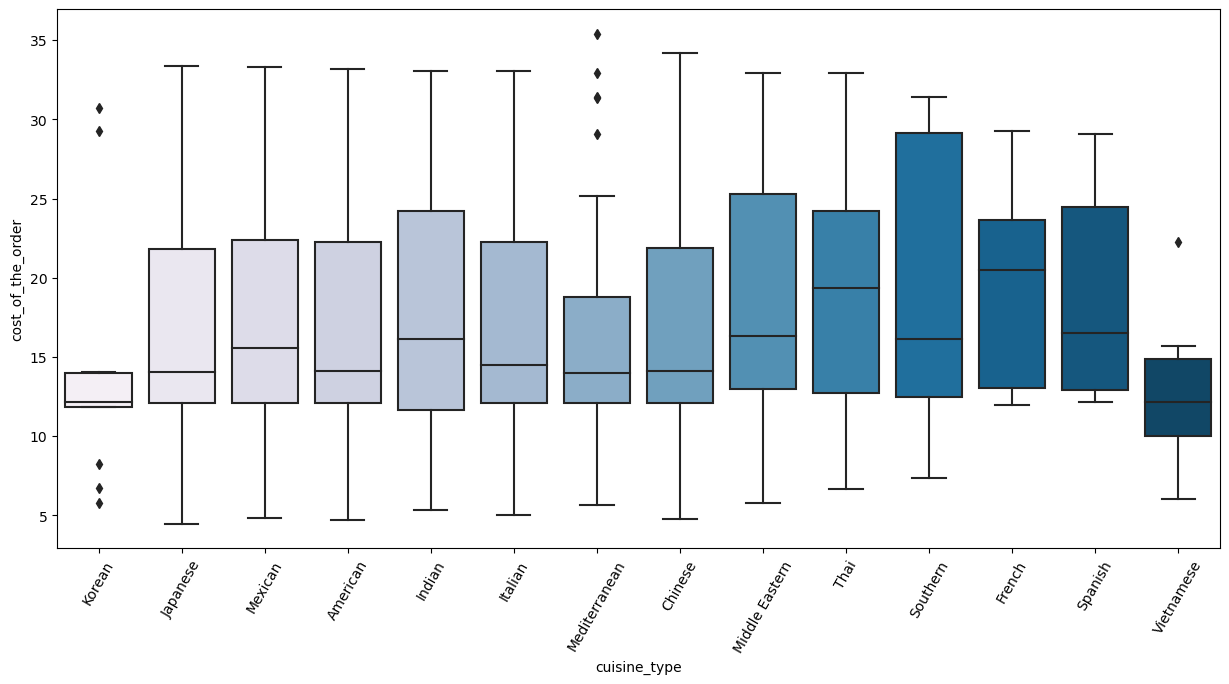

In [33]:
# Relationship between cost of the order and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show()

#### Cuisine vs Food Preparation time

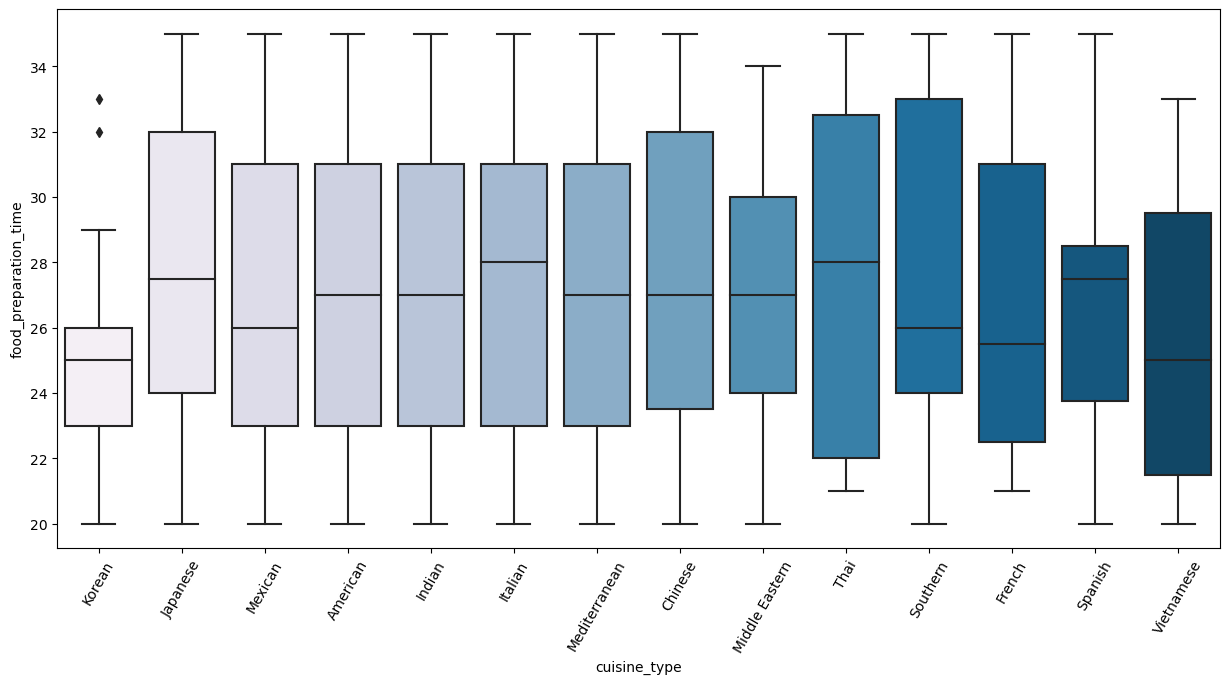

In [34]:
# Relationship between food preparation time and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df,palette = 'PuBu' ) 
plt.xticks(rotation = 60)
plt.show()

#### Day of the Week vs Delivery time

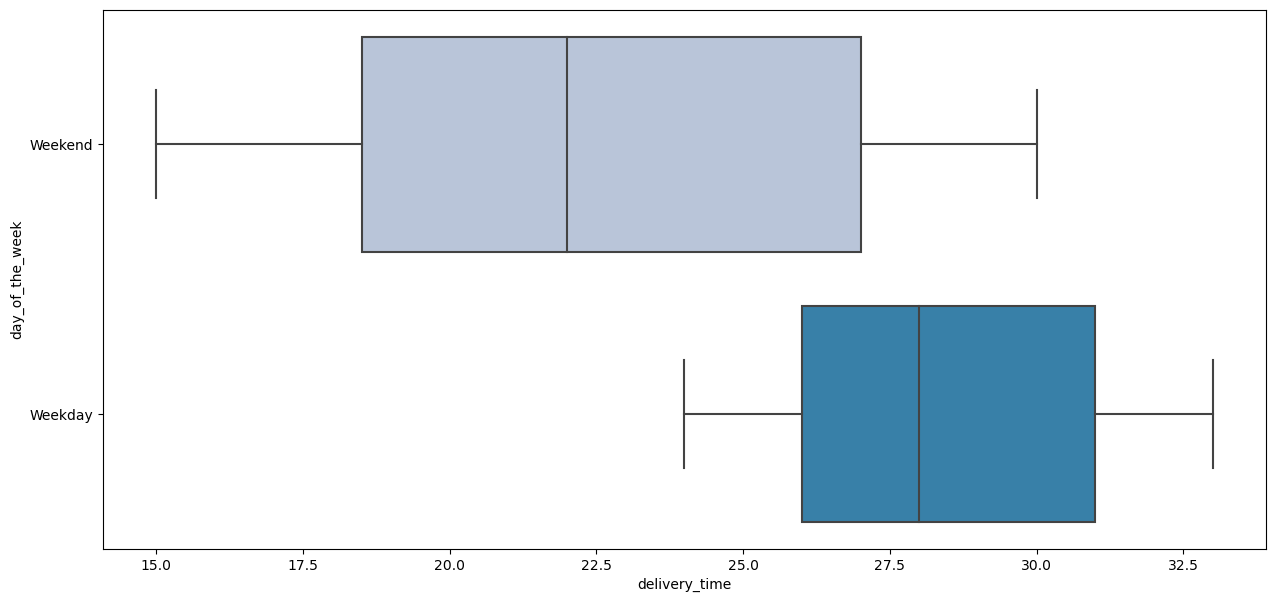

In [35]:
# Relationship between day of the week and delivery time
plt.figure(figsize=(15,7))
sns.boxplot(x='delivery_time',y='day_of_the_week',data=df,palette = 'PuBu') 
plt.show()

#### Run the below code and write your observations on the revenue generated by the restaurants.

In [36]:
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14)

restaurant_name
Shake Shack                      3579.53
The Meatball Shop                2145.21
Blue Ribbon Sushi                1903.95
Blue Ribbon Fried Chicken        1662.29
Parm                             1112.76
RedFarm Broadway                  965.13
RedFarm Hudson                    921.21
TAO                               834.50
Han Dynasty                       755.29
Blue Ribbon Sushi Bar & Grill     666.62
Rubirosa                          660.45
Sushi of Gari 46                  640.87
Nobu Next Door                    623.67
Five Guys Burgers and Fries       506.47
Name: cost_of_the_order, dtype: float64

#### Rating vs Delivery time

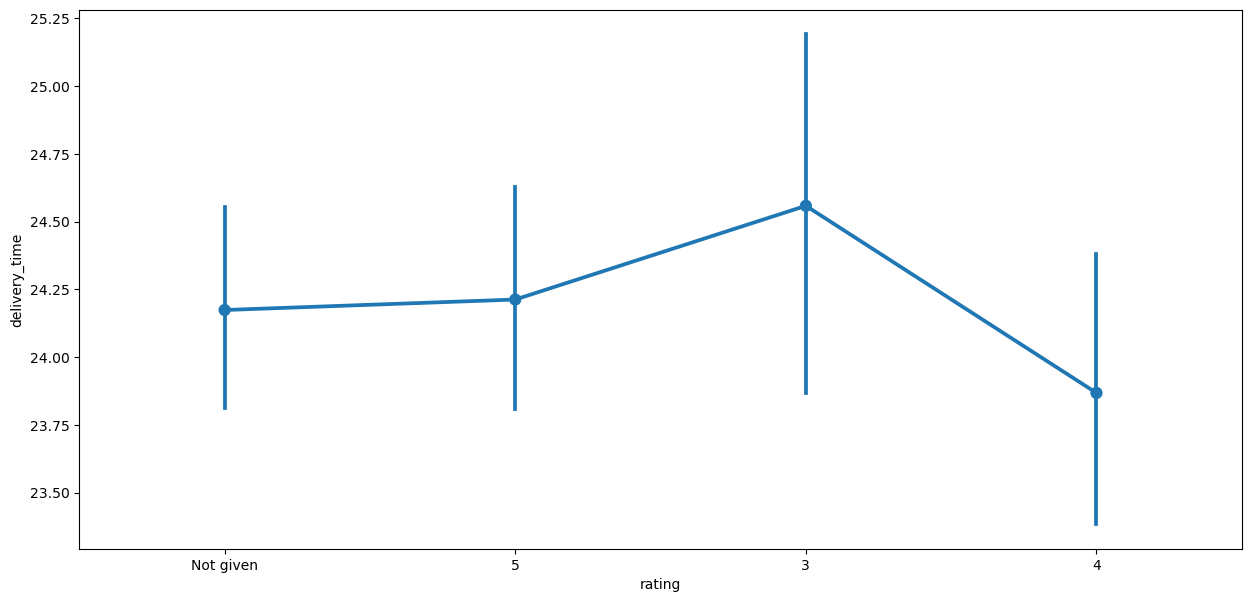

In [37]:
# Relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.show()

In [38]:
#Delivery time of the restaurants
df.groupby(['restaurant_name'])['delivery_time'].max().sort_values(ascending = False).head(20)

restaurant_name
Tres Carnes                              33
Sarabeth's                               33
Vanessa's Dumplings                      33
Burger Joint                             33
Momoya                                   33
Chipotle Mexican Grill $1.99 Delivery    33
Melt Shop                                33
Shake Shack                              33
Mamoun's Falafel                         33
The Meatball Shop                        33
Kanoyama                                 33
Blue Ribbon Sushi                        33
Jack's Wife Freda                        33
Tarallucci e Vino Restaurant             33
J. G. Melon                              33
TAO                                      33
Sarabeth's West                          33
Hatsuhana                                33
Sushi of Gari 46                         33
Hill Country Fried Chicken               33
Name: delivery_time, dtype: int64

#### Rating vs Food preparation time

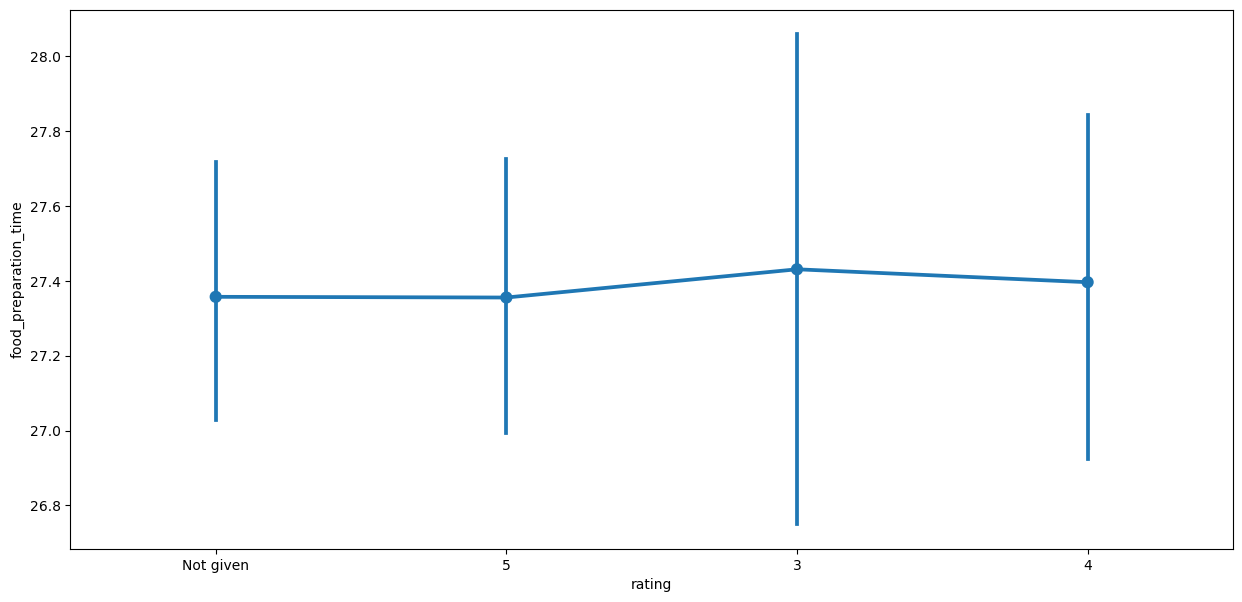

In [39]:
# Relationship between rating and food preparation time
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating',y='food_preparation_time',data=df) 
plt.show()

#### Rating vs Cost of the order

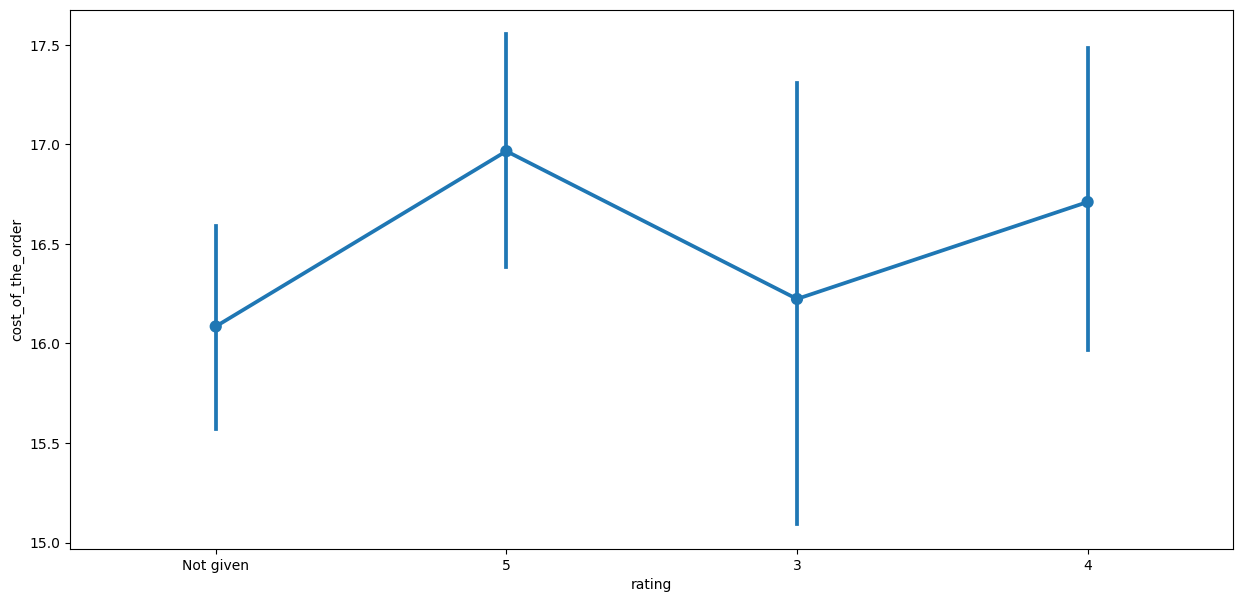

In [40]:
# Relationship between rating and cost of the order
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating',y='cost_of_the_order',data=df)
plt.show()

#### Correlation among variables

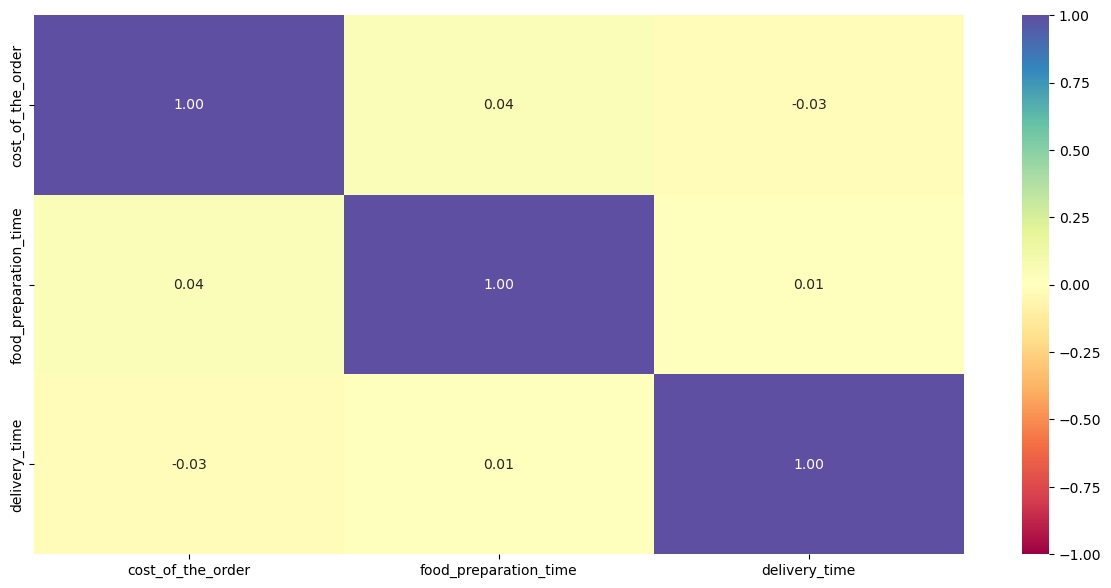

In [41]:
# Plot the heatmap 
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [42]:
# Filter the rated restaurants
df_rated = df[df['rating'] != 'Not given'].copy()

# Convert rating column from object to integer
df_rated['rating'] = df_rated['rating'].astype('int')  

# Create a dataframe that contains the restaurant names with their rating counts
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
df_rating_count.head() 

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [43]:
# Get the restaurant names that have rating count more than 50
rest_names = df_rating_count[df_rating_count['rating']>50]['restaurant_name']  

# Filter to get the data of restaurants that have rating count more than 50
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()

# Group the restaurant names with their ratings and find the mean rating of each restaurant
df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna() 


,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [44]:
#function to determine the revenue
def compute_rev(x):
    if x > 20:
        return x*0.25
    elif x > 5:
        return x*0.15
    else:
        return x*0

df['Revenue'] = df['cost_of_the_order'].apply(compute_rev) 
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,1.7385


In [45]:
# get the total revenue and print it
total_rev = df['Revenue'].sum() 
print('The net revenue is around', round(total_rev, 2), 'dollars')

The net revenue is around 6166.3 dollars


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)[2 marks]


In [46]:
# Calculate total delivery time and add a new column to the dataframe df to store the total delivery time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']


## Write the code below to find the percentage of orders that have more than 60 minutes of total delivery time (see Question 9 for reference)
order_more_than_60_mins = (df['total_time']>60).sum()

total_order=len(df)

percentage_more_than_60_mins=(order_more_than_60_mins/total_order)*100

print('Percentage of order that takes more than 60 mins is:',percentage_more_than_60_mins)


Percentage of order that takes more than 60 mins is: 10.537407797681771


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [47]:
# Get the mean delivery time on weekdays and print it
print('The mean delivery time on weekdays is around', 
      round(df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()),
     'minutes')


## Write the code below to get the mean delivery time on weekends and print it
print('The mean delivery time on weekends is around', 
      round(df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()),
     'minutes')






The mean delivery time on weekdays is around 28 minutes
The mean delivery time on weekends is around 22 minutes


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

# Conclusions: 

'''
* Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm are the most preferred restaurants with higher ratings and order values.

* American cuisine is the most preferred option on weekends, while Vietnamese cuisine is the least preferred.
Conversely, on weekdays, American cuisine remains popular, with Spanish cuisine being the least preferred.

* There are a total of 50 restaurants that have received just one order, indicating potential areas for improvement.

* The food delivery company generates revenue of $6166.3.

* The mean delivery time on weekdays exceeds that on weekends.

* Approximately 10.54% of orders take more than 60 minutes for delivery, indicating potential areas for  improvement.

* There is positive corelation between 

'''


# Recommendation:


'''
* Identify and promote top-performing restaurants such as Shake Shack, The Meatball Shop, and Blue Ribbon Sushi to enhance customer engagement and loyalty.
* Highlight their popular cuisines, high ratings, and customer satisfaction to attract more orders and increase revenue.

* Collaborate with restaurants to diversify their menu offerings, catering to a broader range of customer preferences and tastes.
* Introduce trending cuisines or specialty dishes to attract new customers and encourage repeat orders.

* Implement strategies to optimize delivery routes, reduce delivery times, and enhance overall delivery efficiency.
* Invest in technology for real-time tracking and route optimization to improve customer satisfaction and loyalty.


* Strengthen customer feedback mechanisms by providing interactive platforms for customers to rate their orders and provide feedback.
* Actively monitor and respond to customer feedback to address any concerns promptly and improve overall service quality.


* Introduce loyalty programs or incentives for frequent customers to encourage repeat orders and foster long-term customer relationships.
* Offer exclusive deals, discounts, or rewards for customers who consistently order from the platform or provide positive feedback.


* Explore opportunities to expand into new geographic regions or target demographics based on analysis findings.
* Identify underserved areas or untapped customer segments to expand the customer base and increase market share.

'''